# Lesson 104 — Information leakage in time: audit the prediction

Student edition: implement three TODOs, run each CHECK, then defend your corrected metric.

Tier B: real Wikipedia interaction graph. Small synthetic fixtures isolate clock rules. Full model and trainer are visible below; default execution uses an explicitly provided pretrained checkpoint. Embedded figures work without the lesson page.

In [ ]:
# PROVIDED — standalone environment, no relkit import required.
import sys
print('Python',sys.version.split()[0])
# If needed in a fresh runtime: %pip install torch==2.8.0 numpy==2.2.6 pandas==2.3.2 scikit-learn==1.7.1


## Runtime and evidence

The pinned author GPU runtime uses Python 3.12, torch 2.8.0, NumPy 2.2.6, pandas 2.3.2, scikit-learn 1.7.1. CPU author execution has separately recorded versions. First execution downloads about 534 MiB raw Wikipedia data and a 10 MiB checkpoint; allow roughly 2 GiB RAM for parsing. Raw and checkpoint hashes are verified. Course input URLs become available when the lesson is published; until then use this local checkout. Live Colab remains NOT_CHECKED. Full author evaluation and notebook execution are distinct.

**Your win:** find a time-travel dependency, repair it, and defend the resulting metric. This is the evaluation discipline your relational-learning thesis depends on.

Start with the short audit below. Then follow one prediction through its inputs. The lab uses a trained Temporal Graph Attention (TGAT) model on real Wikipedia interactions; its full model and training recipe remain visible.

## 1 · Retrieval before reading

**Answer the cold retrieval prompts before reading.**

Without opening L103, answer these three questions:

1. A query at time 8 reaches a neighbor through an interaction at time 5. At what time is that neighbor's historical representation queried?
2. In TGN, may the current event update memory before the model predicts that same event?
3. Does putting every test target after the training targets guarantee legal feature access?

**Check after committing your answers**

<p>In TGAT, the child is queried at 5 and its event history is strictly earlier than 5. TGN must predict before incorporating the current outcome. A chronological target split alone cannot constrain joins, feature versions, sampled neighbors, memory, or model selection.</p>

**Where we are.** [L102](https://avistian.github.io/relational/lessons/0102-temporal-graph-networks.html) introduced persistent memory. [L103](https://avistian.github.io/relational/lessons/0103-tgat.html) recomputed embeddings from history. Both still need an explicit rule for what was knowable. A timestamp inside a neural network does not enforce that rule.

## 2 · First define the prediction moment

> **In plain terms.** Imagine stopping the application immediately before it must answer. Which records could it read at that instant?

A **prediction query** names an entity or candidate pair and a prediction time, τ. **Event time**, s, says when something happened. **Availability time**, a, says when the predictor could first read that record or feature version. A delayed report can have s < τ but a > τ.

For this lesson's before-event prediction task, a historical record is eligible when:

**s < τ and a ≤ τ.**

The first inequality excludes the event being predicted and all timestamp ties. The second excludes late arrivals. We assume a record stamped available at τ has been committed before the query; systems with different tie ordering need a stricter rule or an explicit sequence number. A time zone conversion cannot recover missing ordering information.

**Worked example.** Predict at day 8. An interaction occurred at day 3 and was received at day 4: legal. A correction describes day 3 but was received at day 9: illegal. An event occurring at day 8 is also excluded under this task's strict-before convention. Select the historical feature version that existed then, not today's overwritten value.

<figure class="audit-figure" tabindex="0">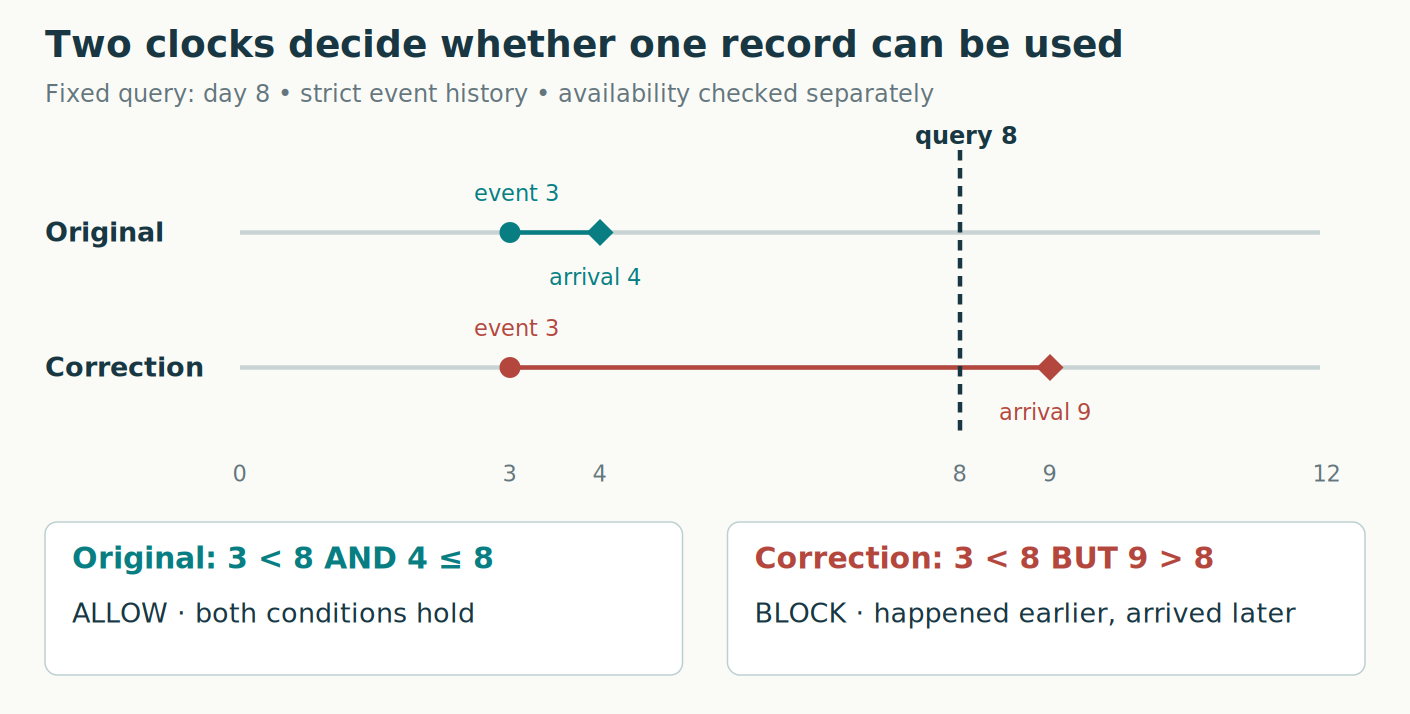<figcaption>Same historical event, different arrival. At query day 8, the day-9 correction must be excluded even though its event date is day 3.</figcaption></figure>

**Portable state:** event day 3, arrival day 9, query day 8 → BLOCK. Change arrival to 7 → ALLOW. The interactive lesson lets you vary arrival time.

**Predict the control.** At query day 8, moving the correction's arrival from day 9 to day 7 should change its eligibility even though its event date stays day 3. The default worked state above remains the comparison baseline.

### Different tasks can have different boundaries

Fey et al.'s relational blueprint uses query timestamps to build time-consistent computation graphs and describes entity timestamps up to the query time. TGAT reconstructs event history strictly before a query, including recursive child requests. These are task conventions, not interchangeable punctuation. A database snapshot prediction can legitimately read a committed row at its cutoff; an interaction predictor cannot read its own target event. See [Fey §§2.2–3.3 and Appendix A](https://proceedings.mlr.press/v235/fey24a.html) and [TGAT §3.2](https://arxiv.org/html/2002.07962v1#S3.S2).

> **Scope check.** Wikipedia provides event timestamps, not ingestion histories or historical feature versions. Our real-data experiment assumes availability equals event time. The delayed-arrival examples are diagnostic fixtures, not measured Wikipedia delays.

## 3 · A legal root can hide an illegal child

A **computation graph** is the set of records and intermediate calculations actually used to produce one prediction. A **temporal neighborhood** is the eligible incident-event history retrieved for a node at its current cutoff.

**Worked example.** Query A at time 8. An A–B event at time 5 is legal. TGAT next needs B's representation at time 5. A B–C event at time 6 is earlier than the root time 8, but later than the child time 5. Filtering every hop against 8 would leak into the historical representation of B.

<figure class="audit-figure" tabindex="0">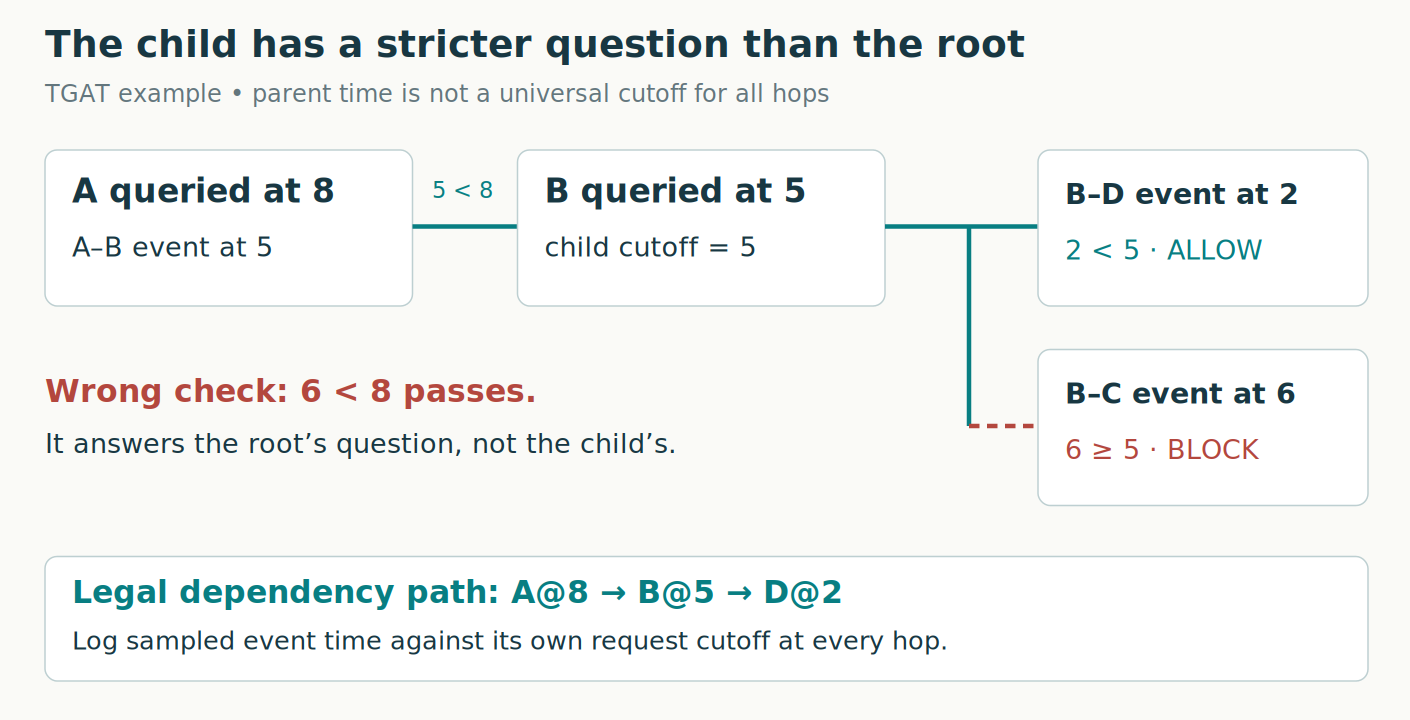<figcaption>Trace 8 → 5 → 2. A record at 6 is illegal for the child requested at 5, even though it predates the root query.</figcaption></figure>

The rule belongs to every recursive request. TGAT sends the connecting event time to its child. For this event-recursive computation, legal times decrease along the path: 8 → 5 → 2. A 6 on the second hop violates the child boundary. Other temporal architectures may define a snapshot neighborhood at one root time; audit the model's actual contract before transferring TGAT's recursion rule to them.

**The full path being audited:** candidate endpoints and τ → sampled histories → two shared TGAT attention layers → two 172-dimensional endpoint vectors → pair decoder → a probability. Time and edge features enter attention. The graph sampler therefore controls which evidence can influence both the positive candidate and its negative comparison. The complete encoder and trainer are provided in the notebook; this lesson changes the sampler, not that architecture.

### State and caches are also inputs

For TGN, a memory vector is a summary of prior observations. Audit the events that entered it, including pending messages. Predicting an event after incorporating its outcome is a dependency violation even if the input tensor carries an older timestamp. Likewise, a cached embedding (a computed vector for an entity) keyed only by node ID can accidentally serve a vector computed from later history. Include the cutoff and relevant data/model version in cache identity, or show that the cached representation is valid for every requested time.

**Check:** a model contains no recurrent memory. Is it immune? No: TGAT can leak through its retrieved neighborhood or raw feature versions.

## 4 · Labels and selection have their own clocks

> **In plain terms.** A label can describe the future of an old query and still be unavailable when you fit the model.

A **prediction horizon** is the future interval whose outcome defines the target. **Label maturity** is when that entire outcome, including reporting delay, can be known. For a horizon H and delay d, a simple target matures at τ + H + d. This formula assumes both are known and fixed; real tasks may require a recorded maturity timestamp.

**Worked example.** Fit on day 10. Query day 4 predicts activity over the next 5 days, with a 2-day reporting delay. Its target matures on day 11. Despite the old query date, that target is unavailable at fitting time. A query from day 2 with the same horizon and delay matures on day 9 and is eligible.

<figure class="audit-figure" tabindex="0">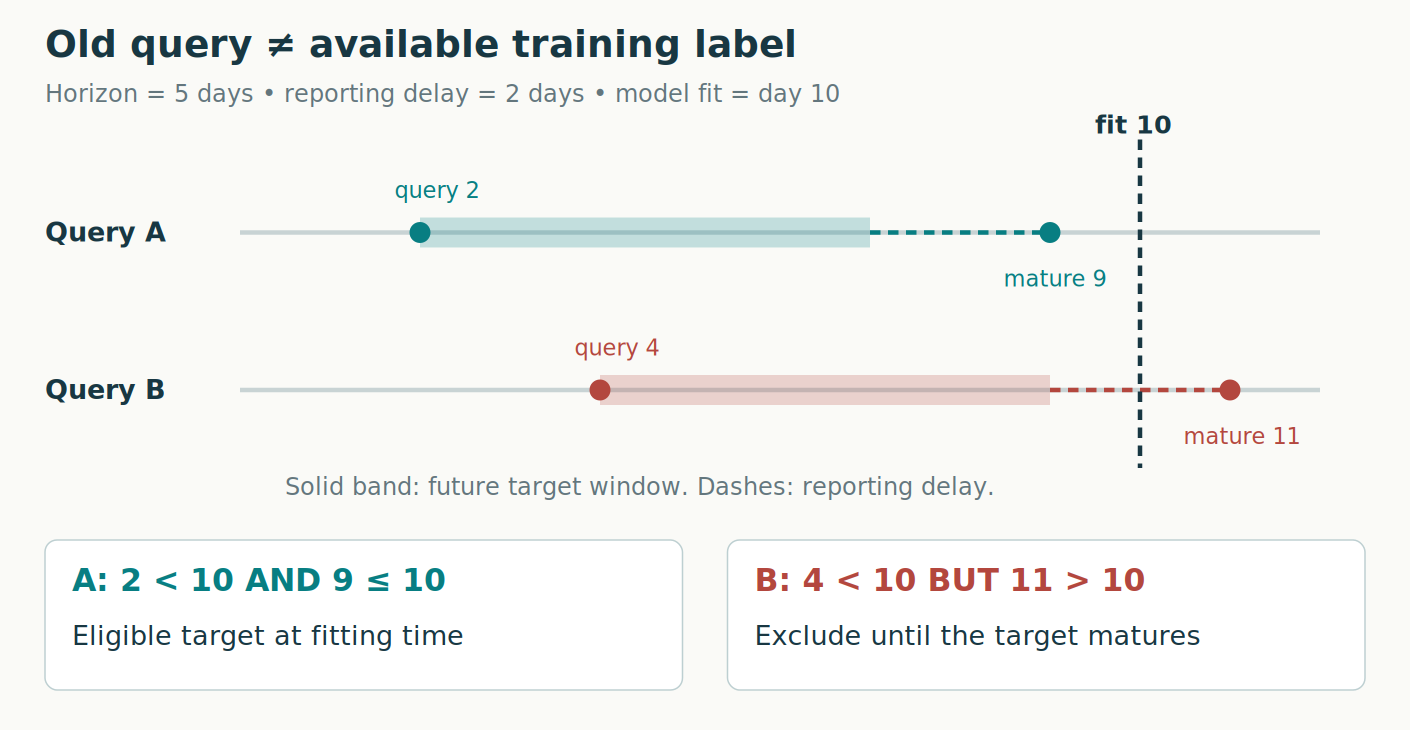<figcaption>Targets must be complete when fitting starts. Both queries are old, but only query A has a mature target at day 10.</figcaption></figure>

Our training audit requires **query time < fit time and label-availability time ≤ fit time**. An embargo, a gap between splits, can help implement this for fixed horizons. A guessed gap does not prove every target has matured. Check the actual label clock.

A **checkpoint** is a saved model state. **Model selection** chooses a state or setting using measured performance. Suppose the model will serve on day 20. Selecting it using validation outcomes that mature on day 25 uses knowledge unavailable on day 20. Sorting the test table cannot repair that choice. Record when training labels, validation outcomes, fitted preprocessors and the chosen model all became available.

In a declared online evaluation, earlier observed test events may legitimately become history for later predictions. Test labels cannot silently become fitting or selection inputs. State whether the service observes interactions after they occur, whether updates happen per event or per batch, and when it is retrained.

## 5 · Turn the claim into an audit

[Kapoor and Narayanan](https://arxiv.org/abs/2207.07048) distinguish temporal evaluation mismatch, illegitimate features, and contamination between training and test processing. Their model-info-sheet approach asks for reasons that the measured task supports the scientific claim. Here we specialize that reasoning to a temporal graph; we are not reproducing their civil-war experiments.

| Inspect | Counterexample to look for | Evidence of repair |
|---|---|---|
| Input versions | A backfilled attribute describes an old event but arrived later | Historical version and availability checks |
| Every sampled hop | Child time 5 reads event time 6 | Sampled dependency log against each child cutoff |
| Current interaction | The candidate edge enters its own history | Equal-time fixture plus sampled-event audit |
| Memory and caches | State from a later query is reused earlier | Replay from legal state; cutoff-aware cache identity |
| Fitting targets | Old query has an unmatured target | Query and label-availability masks |
| Selection and preprocessing | Future outcomes select an earlier deployed model | Fit/selection timestamps and untouched test labels |
| Metric comparison | Repair changes candidates or evaluated rows | Paired event IDs, negatives and aggregation |

An **assertion** is a condition the program checks and refuses to violate. A **counterexample** is one concrete case that disproves a proposed guarantee. Use both: trace one forbidden path, then test a broader boundary set including empty histories and timestamp ties. A high AP is not such a guarantee.

## 6 · The controlled Wikipedia experiment

### Two experiments with different purposes

**A. Released-evaluation replay.** Restore each completed L103 checkpoint and its saved NumPy random state. Recompute the complete released all-test and new-node-test predictions. Check event IDs, negative destinations and every saved probability. This tests whether the published-experiment implementation and its archived output can be replayed. It reuses L103 training.

**B. Leakage intervention.** Keep that checkpoint fixed and ask the same prediction questions under three information-access rules:

| Arm | Allowed event history at each recursive cutoff c | Interpretation |
|---|---|---|
| Strict | s < c | Corrected course baseline |
| Inclusive | s ≤ c | Illegal same-time access for this task |
| Lookahead | s ≤ c + 86,400 seconds | Illegal one-day lookahead at every recursive request |

For a true interaction (u, v, t), inclusive history can contain that very interaction while the model is trying to predict it. A sampled negative pair often has no corresponding current edge. This can reveal part of the answer through graph structure.

These are inference interventions; no arm retrains the model. Negatives come from the archived evaluation, so the candidate pairs and labels stay fixed. Each sampler call draws a uniform matrix even when a node has no history. Resetting the seed for each arm then gives a common random-number schedule. The same uniforms may select different neighbors from changed eligible sets; holding neighbors identical would prevent the access intervention itself. Because the fanout (the number of samples per request) stays at 20 records, illegal records can also displace legitimate ones. That is part of this access-rule intervention and another reason the score need not rise.

The release sampler drops one eligible item and consumes random numbers differently on empty histories. Its historical baseline is therefore **not** the causal baseline for B. We separately compare each illegal arm to the corrected strict arm. Release early stopping, omitted last events, and batch-mean AP remain documented in the [reproduction contract](https://avistian.github.io/relational/labs/l104-reproduction.md).

**Read the actual sampler.** `uniforms` is drawn before inspecting individual histories, so an empty row cannot shift later random draws. The audit compares each sampled timestamp to that request's cutoff; zero-padding slots do not count as historical records. The eligibility policy is the notebook's first TODO.

```python
    def get_temporal_neighbor(self, nodes, cutoffs, num_neighbors=20):
        ids = np.zeros((len(nodes),num_neighbors), dtype=np.int32)
        edges = np.zeros_like(ids); times = np.zeros(ids.shape, dtype=np.float32)
        # Draw even for empty histories. This preserves the uniform schedule across arms.
        uniforms = np.random.random((len(nodes),num_neighbors))
        for i,(node,cutoff) in enumerate(zip(nodes,cutoffs)):
            history = self.find_before(node,cutoff)
            if not len(history):
                continue
            selected = history[np.floor(uniforms[i]*len(history)).astype(int)]
            selected = selected[np.argsort(selected[:,2])]
            ids[i], edges[i], times[i] = selected[:,0], selected[:,1], selected[:,2]
            self.audit['sampled_records'] += len(selected)
            self.audit['nonpast_records'] += int(np.sum(selected[:,2] >= cutoff))
            self.audit['future_records'] += int(np.sum(selected[:,2] > cutoff))
        self.audit['queries'] += len(nodes)
        return ids, edges, times
```

### What is measured?

**Precision** is the fraction of selected candidates that are positives. **Recall** is the fraction of all evaluated positives that have been selected. **Average precision (AP)** summarizes a ranking by averaging precision at recall increases. Higher scores for positives generally improve it, but tied scores are grouped. We use the implementation in the [scikit-learn AP definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

The released experiment reports an unweighted mean of per-batch AP. The intervention reports **pooled AP**, computed once over all positive and sampled-negative scores in one evaluation population. These aggregations can differ because AP is nonlinear. A **percentage point (pp)** is an absolute difference on the percentage scale: AP .90 to .92 is +2 pp. Our paired change is 100 × (AP_illegal − AP_strict).

Each positive has one sampled negative; occasional collisions are preserved from L103. This measures sampled-candidate discrimination, not ranking against every possible page. Candidate pools are inherited from the release and can use the full graph’s node roster; the strict sampler audit does not certify that roster was known to a deployed service. The new-node subset contains events with at least one endpoint absent from training. It overlaps the all-test population, so these are not independent replications.

**Predict first:** must access to future information increase AP for fixed weights?

**Before revealing results:** must illegal history improve AP? Write a direction for each arm and a reason. The trained model may respond poorly to inputs it never saw during training. An invalid information path stays invalid even when it reduces the metric.

**Reveal the author measurements after making your prediction**



**Fresh evaluation: COMPLETE, 10/10 checkpoints.** Training was reused from L103.

| Population | Strict pooled AP | Same-time AP change | One-day AP change |
|---|---:|---:|---:|
| All test events | 95.8643% | +0.6431 ± 0.2538 pp | +1.0928 ± 0.1808 pp |
| New-node subset | 94.8299% | +1.2065 ± 0.2717 pp | +1.8212 ± 0.2765 pp |

± is sample SD across seeds, not a confidence interval. Released replay checked **353,340 positive events**, each with one negative, with maximum probability error **0**. Strict sampled nonpast accesses: **0**.

**Paper-target check (separate aggregation):**

| Released population | Fresh batch-mean AP ± seed SD | Original paper target | Numerical verdict |
|---|---:|---:|---|
| All test events | 95.2825% ± 0.2784 pp | 95.34% | CLOSE |
| New-node subset | 93.7792% ± 0.3912 pp | 93.99% | CLOSE |

The predeclared ±0.5 pp numerical tolerance does not establish matching historical populations or full-paper parity. **Historical identity INCOMPARABLE; full-paper parity NOT_ESTABLISHED.** [Machine-readable evidence](https://avistian.github.io/relational/labs/_analysis_l104_results.json).

<figure class="audit-figure" tabindex="0">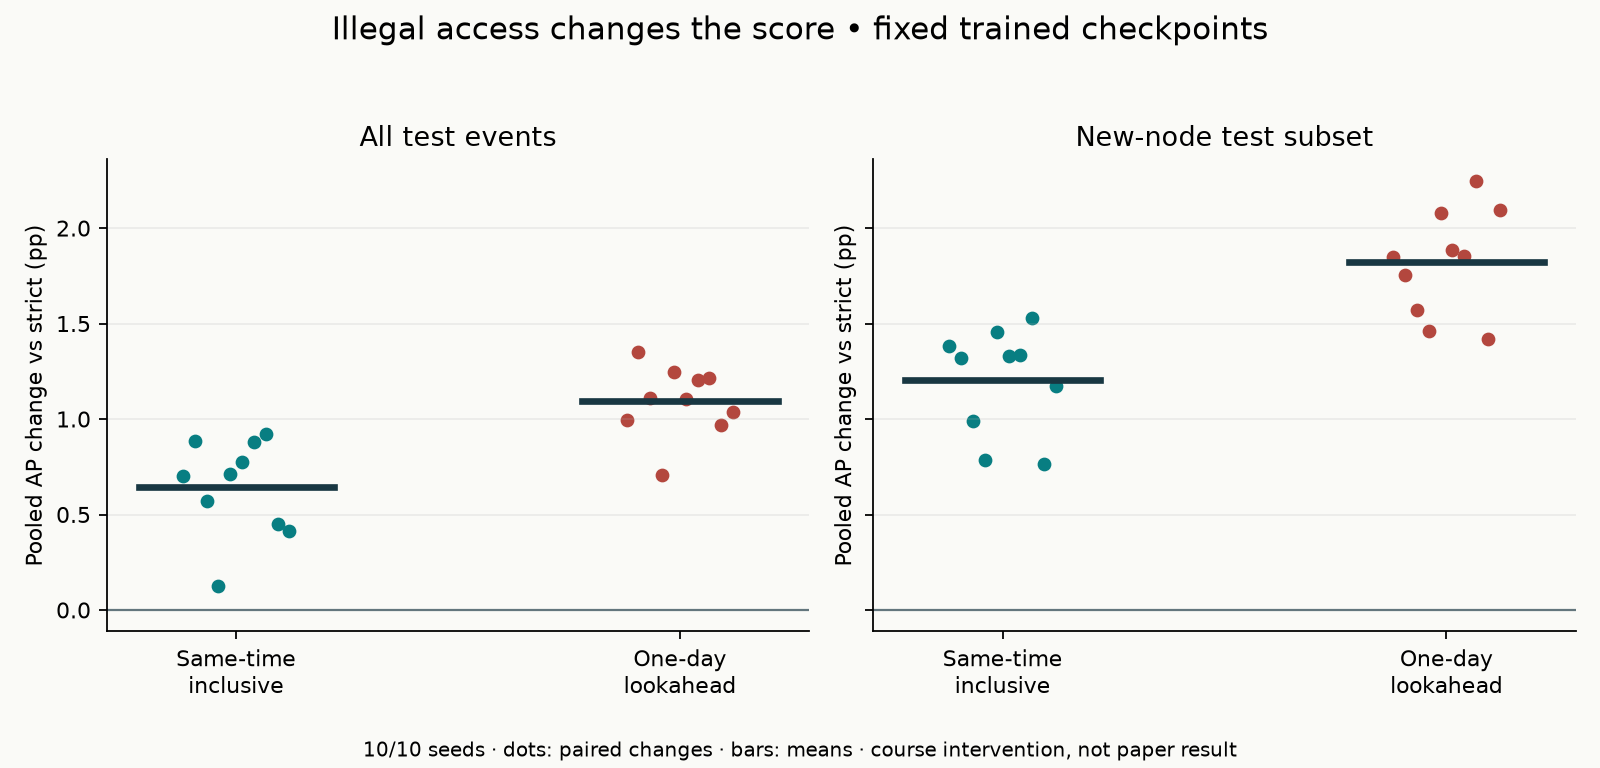<figcaption>Fixed weights and prediction questions; each dot is one seed’s paired pooled-AP difference from the corrected strict baseline. Both illegal arms remain invalid regardless of score direction.</figcaption></figure>



**A concrete detected bug.** The instrumented seed-0 run requests node 3174 at time 2,218,300 seconds. The inclusive sampler reads edge 133854 at exactly 2,218,300. The lookahead sampler reads edge 133879 at 2,218,624—324 seconds after that request. Both violate this request's strict cutoff. Instrumentation left every checked prediction byte-identical; the [witness log](https://avistian.github.io/relational/labs/_witness_l104_results.json) records these actual sampled dependencies. This log captures individual requests, not a reconstructed complete parent chain.

**A causal repair check.** On a small diagnostic graph, changing only future feature rows leaves strict predictions exactly unchanged. The lookahead positive control changes a probability by about 0.150. This separate [metamorphic test](https://avistian.github.io/relational/labs/_causality_l104_results.json) validates a property of the sampler; its synthetic number is not a Wikipedia score.

The audit records sampled nonpast edges relative to the cutoff of each request. Counts include repeated samples and repeated recursive requests, not unique leaked database rows. The lookahead window resets at every hop; it is not a single root-level horizon. Strict zero violations establish this sampler's timestamp invariant, not a proof that the underlying features were historically available.

A **random seed** fixes a random generator’s starting state. Replaying its draws also requires matching the call order and runtime. Across-seed standard deviations describe checkpoint and sampling variation on this fixed graph and split. They do not measure uncertainty across future deployments or datasets. Negative examples differ across L103 seeds but are paired across arms within each seed. A result is evidence about this intervention, not a universal benefit of leakage.

## 7 · Lab: repair the boundary and defend the number

Open the [student notebook](https://avistian.github.io/relational/labs/0104-information-leakage-in-time.ipynb) or the [prepared executed walkthrough](https://avistian.github.io/relational/labs/html/0104-information-leakage-in-time.html). Try the three tasks before consulting the [teacher solution](https://avistian.github.io/relational/labs/solutions/0104-information-leakage-in-time.ipynb).

1. **TODO — eligibility:** implement event-time and availability-time filtering. CHECK empty histories, ties and late arrivals. Your function is called by the live neighborhood sampler.
2. **TODO — label maturity:** decide which training targets were knowable at fitting time. CHECK that an old query can still have a future target.
3. **TODO — paired AP:** reject mismatched event IDs, negative destinations or batches before computing the score difference. CHECK a deliberate negative-sample mismatch.

The default notebook evaluates 120 positive questions and 120 sampled negatives from one full-data trained checkpoint under each arm. This is a small execution exercise, distinct from the complete author evaluation. It downloads checksum-pinned data and a provided checkpoint when absent. The model and complete trainer are visible inline; the checkpoint is an explicit pretrained input.

**EXIT — submit four things:** the three functions; your measured AP table; one exact forbidden dependency (event time, cutoff and path); and a written defense of the repaired result. Explain why correct timestamp filtering cannot certify unknown arrival times. Explain which training was reused and which predictions you generated yourself. Status stays **PENDING_WRITTEN_DEFENSE** until you supply that evidence.

## 8 · Reproduce and extend

The [reproduction contract](https://avistian.github.io/relational/labs/l104-reproduction.md) contains pinned inputs, runtime, exact local/Modal commands, the budget, and deviations. It also links the complete L103 training recipe. Keep **fresh evaluation**, **reused training**, **course interventions**, and **unrun paper coverage** separate.

An adversarial extension: perturb every inaccessible future row while keeping accessible data fixed. For a strictly causal predictor, current outputs should remain unchanged when the random schedule is fixed. This is a **metamorphic test**: check how an output should respond to a controlled input transformation even when the exact output is unknown. It complements observed-edge audit logs; it does not replace availability provenance.

**Teach back:** explain the corrected number and the provenance limits in your own words before consulting the solution.

**Read next:** Kapoor & Narayanan's taxonomy and model-info-sheet sections, then Fey §§2.2–3.3. [Reference card](https://avistian.github.io/relational/reference/temporal-leakage-audit.html) · [Temporal glossary](https://avistian.github.io/relational/reference/glossary.html#temporal-l101). Ask the tutor about any unclear boundary or paste your EXIT defense for review. Lesson 105 will ask how continuous-time event streams differ from snapshots; carry the prediction-time contract into that choice.


## PROVIDED · Complete TGAT model and training recipe

This is the unchanged canonical L103 implementation, including its released neighbor-boundary, batch and checkpoint-selection quirks. Read the recursion carefully. The intervention does not call the release sampler; it replaces it with AuditFinder after restoring the trained weights. Each named chunk is visible, so there is no hidden model import.

### PROVIDED · Imports and frozen identities

In [ ]:
import copy
import hashlib
import json
import math
import random
import time
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.metrics import average_precision_score, roc_auc_score
SOURCE_COMMIT='9293d10d1943c4bd4a186337cf38ba98e4c8bb99'
DATA_URL='https://snap.stanford.edu/jodie/wikipedia.csv'
DATA_SHA256='a6b73e09c0d1e5b9db11e7e7aa416f2e87838a745273e0446a79952cf4cfae09'
PAPER_AP={'all':95.34,'new':93.99}
CLOSE_TOLERANCE_PP=0.5

### PROVIDED · L103 mechanism · functional time encoding, release parameterization

In [ ]:
def encode_time(elapsed, frequency, phase):
    """Map elapsed [B,N] and trainable [D] frequencies/phases to [B,N,D]."""
    return torch.cos(elapsed.unsqueeze(-1)*frequency+phase)

### PROVIDED · L103 mechanism · scaled masked attention

In [ ]:
def attention_weights(query, keys, padding):
    """[H*B,1,D] x [H*B,N,D] -> [H*B,1,N]; True means padding.
    Preserve the release's finite -1e10 mask, including uniform all-padding rows.
    """
    scores=torch.bmm(query,keys.transpose(1,2))/math.sqrt(query.shape[-1])
    return torch.softmax(scores.masked_fill(padding,-1e10),dim=-1)

### PROVIDED · L103 mechanism · strict-past temporal boundary for the corrected comparison

In [ ]:
def strict_prefix(sorted_times, cutoff):
    """Number of events strictly before cutoff; exclude every equal timestamp."""
    return int(np.searchsorted(sorted_times,cutoff,side='left'))

### PROVIDED · Temporal neighborhoods: declared release behavior or corrected boundary

In [ ]:
class NeighborFinder:
    def __init__(self, events, n_nodes, release=True, uniform=True):
        rows=[[] for _ in range(n_nodes)]
        for u,v,t,e in zip(events['u'],events['v'],events['t'],events['e']):
            rows[int(u)].append((int(v),int(e),float(t)))
            rows[int(v)].append((int(u),int(e),float(t)))
        # Release sorts by edge ID. For this stream, IDs are chronological.
        self.rows=[np.asarray(sorted(r,key=lambda z:z[1] if release else z[2]),dtype=np.float64).reshape(-1,3) for r in rows]
        self.release,self.uniform=release,uniform
    def find_before(self,node,cutoff):
        a=self.rows[int(node)];ts=a[:,2]
        if not self.release:
            end=strict_prefix(ts,cutoff)
        elif not len(a):
            end=0
        else:
            # Exact released binary-search/slice convention, including its omitted item.
            left,right=0,len(a)-1
            while left+1<right:
                middle=(left+right)//2
                if ts[middle]<cutoff:left=middle
                else:right=middle
            end=right if ts[right]<cutoff else left
        return a[:end]
    def get_temporal_neighbor(self,nodes,cutoffs,num_neighbors=20):
        ids=np.zeros((len(nodes),num_neighbors),dtype=np.int32)
        edges=np.zeros_like(ids);times=np.zeros(ids.shape,dtype=np.float32)
        for i,(node,cutoff) in enumerate(zip(nodes,cutoffs)):
            history=self.find_before(node,cutoff)
            if not len(history):continue
            if self.uniform:
                chosen=history[np.random.randint(0,len(history),num_neighbors)]
                ids[i],edges[i],times[i]=chosen[:,0],chosen[:,1],chosen[:,2]
                order=times[i].argsort();ids[i],edges[i],times[i]=ids[i,order],edges[i,order],times[i,order]
            else:
                chosen=history[:num_neighbors] if self.release else history[-num_neighbors:]
                ids[i,-len(chosen):],edges[i,-len(chosen):],times[i,-len(chosen):]=chosen[:,0],chosen[:,1],chosen[:,2]
        return ids,edges,times

### PROVIDED · Trainable encoder and feed-forward merge

In [ ]:
class TimeEncoder(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.basis_freq=nn.Parameter(torch.tensor(1/10**np.linspace(0,9,dim),dtype=torch.float32))
        self.phase=nn.Parameter(torch.zeros(dim))
    def forward(self,elapsed):return encode_time(elapsed,self.basis_freq,self.phase)

class Merge(nn.Module):
    def __init__(self,left,right,hidden,out):
        super().__init__();self.fc1=nn.Linear(left+right,hidden);self.fc2=nn.Linear(hidden,out)
        nn.init.xavier_normal_(self.fc1.weight);nn.init.xavier_normal_(self.fc2.weight)
    def forward(self,left,right):return self.fc2(torch.relu(self.fc1(torch.cat([left,right],dim=-1))))

### PROVIDED · Multi-head attention: projection, aggregation, residual and normalization

In [ ]:
class MultiHead(nn.Module):
    def __init__(self,width,heads,dropout):
        super().__init__();assert width%heads==0
        self.heads,self.head_dim=heads,width//heads
        self.w_qs=nn.Linear(width,width,bias=False);self.w_ks=nn.Linear(width,width,bias=False);self.w_vs=nn.Linear(width,width,bias=False)
        for layer in [self.w_qs,self.w_ks,self.w_vs]:nn.init.normal_(layer.weight,std=np.sqrt(2/(width+self.head_dim)))
        self.layer_norm=nn.LayerNorm(width);self.fc=nn.Linear(width,width);nn.init.xavier_normal_(self.fc.weight)
        self.dropout=nn.Dropout(dropout)
    def forward(self,q,k,mask):
        batch=q.shape[0]
        def split(x,projection):
            return projection(x).view(batch,-1,self.heads,self.head_dim).permute(2,0,1,3).contiguous().view(self.heads*batch,-1,self.head_dim)
        query,keys,values=split(q,self.w_qs),split(k,self.w_ks),split(k,self.w_vs)
        weights=self.dropout(attention_weights(query,keys,mask.repeat(self.heads,1,1)))
        mixed=torch.bmm(weights,values).view(self.heads,batch,1,self.head_dim).permute(1,2,0,3).contiguous().view(batch,1,-1)
        return self.layer_norm(q+self.dropout(self.fc(mixed)))

class TemporalAttention(nn.Module):
    def __init__(self,dim,heads,dropout):
        super().__init__();self.merger=Merge(3*dim,dim,dim,dim);self.multi_head_target=MultiHead(3*dim,heads,dropout)
    def forward(self,source,zero_time,neighbors,elapsed,edge,padding):
        q=torch.cat([source[:,None,:],torch.zeros_like(source[:,None,:]),zero_time],dim=-1)
        kv=torch.cat([neighbors,edge,elapsed],dim=-1)
        context=self.multi_head_target(q,kv,padding[:,None,:]).squeeze(1)
        return self.merger(context,source)

### PROVIDED · Complete recursive TGAT encoder and shared positive/negative decoder

In [ ]:
class TGAT(nn.Module):
    def __init__(self,finder,node_features,edge_features,layers=2,heads=2,dropout=.1):
        super().__init__();self.num_layers=layers;self.ngh_finder=finder
        # Preserve release registration and initialization order for parity checks.
        self.n_feat_th=nn.Parameter(torch.as_tensor(node_features,dtype=torch.float32))
        self.e_feat_th=nn.Parameter(torch.as_tensor(edge_features,dtype=torch.float32))
        self.edge_raw_embed=nn.Embedding.from_pretrained(self.e_feat_th,padding_idx=0,freeze=True)
        self.node_raw_embed=nn.Embedding.from_pretrained(self.n_feat_th,padding_idx=0,freeze=True)
        d=node_features.shape[1];assert edge_features.shape[1]==d
        self.merge_layer=Merge(d,d,d,d) # unused released module, retained for RNG/state identity
        self.attn_model_list=nn.ModuleList([TemporalAttention(d,heads,dropout) for _ in range(layers)])
        self.time_encoder=TimeEncoder(d);self.affinity_score=Merge(d,d,d,1)
    def tem_conv(self,nodes,cutoffs,layer,num_neighbors=20):
        device=self.n_feat_th.device
        raw=self.node_raw_embed(torch.as_tensor(nodes,dtype=torch.long,device=device))
        if layer==0:return raw
        source=self.tem_conv(nodes,cutoffs,layer-1,num_neighbors)
        nbr,eid,when=self.ngh_finder.get_temporal_neighbor(nodes,cutoffs,num_neighbors)
        child=self.tem_conv(nbr.ravel(),when.ravel(),layer-1,num_neighbors).reshape(len(nodes),num_neighbors,-1)
        elapsed=torch.as_tensor(cutoffs[:,None]-when,dtype=torch.float32,device=device)
        time_features=self.time_encoder(elapsed)
        zero_time=self.time_encoder(torch.zeros((len(nodes),1),device=device))
        edge=self.edge_raw_embed(torch.as_tensor(eid,dtype=torch.long,device=device))
        padding=torch.as_tensor(nbr==0,device=device)
        return self.attn_model_list[layer-1](source,zero_time,child,time_features,edge,padding)
    def contrast(self,u,v,negative,t,num_neighbors=20):
        src=self.tem_conv(u,t,self.num_layers,num_neighbors)
        dst=self.tem_conv(v,t,self.num_layers,num_neighbors)
        neg=self.tem_conv(negative,t,self.num_layers,num_neighbors)
        return self.affinity_score(src,dst).flatten().sigmoid(),self.affinity_score(src,neg).flatten().sigmoid()

### PROVIDED · Hash-checked raw Wikipedia preprocessing and frozen temporal split

In [ ]:
def load_wikipedia(directory):
    directory = Path(directory); directory.mkdir(parents=True, exist_ok=True)
    path = directory/'wikipedia.csv'
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL, path)
    sha = hashlib.file_digest(path.open('rb'), 'sha256').hexdigest()
    assert sha == DATA_SHA256, f'Dataset checksum mismatch: {sha}'
    cache = directory/'processed.npz'
    if cache.exists():
        z = np.load(cache)
        # The raw identity alone cannot authenticate an arbitrary processed cache.
        if str(z['raw_sha']) != sha:
            raise ValueError('Processed cache belongs to other raw bytes')
        u,v,t,x = (z[k] for k in ['u','v','t','x'])
    else:
        # Header has four columns, rows additionally have 172 edge features.
        a = np.loadtxt(path, delimiter=',', skiprows=1)
        u = a[:, 0].astype(np.int64)+1
        v = a[:, 1].astype(np.int64)+int(u.max())+1
        t,x = a[:, 2], a[:, 4:].astype(np.float32)
        np.savez(cache, u=u,v=v,t=t,x=x,raw_sha=sha)
    assert len(u)==157474 and x.shape==(157474,172)
    assert np.all(np.diff(t)>=0) and len(set(u)|set(v))==9227
    edges = np.vstack([np.zeros((1,172),np.float32),x])
    nodes = np.zeros((int(max(u.max(),v.max()))+1,172),np.float32)
    full = {'u':u,'v':v,'t':t,'e':np.arange(1,len(u)+1)}
    val_time,test_time = np.quantile(t,[.70,.85])
    candidates = set(u[t>val_time]) | set(v[t>val_time])
    # Python 3.9 random.sample(set, k) internally converted to tuple. Preserve that order.
    held = set(random.Random(2020).sample(tuple(candidates),int(.1*(len(nodes)-1))))
    train_mask = (t<=val_time)&~np.isin(u,list(held))&~np.isin(v,list(held))
    seen = set(u[train_mask])|set(v[train_mask]); unseen=(set(u)|set(v))-seen
    novel = np.isin(u,list(unseen))|np.isin(v,list(unseen))
    masks={'train':train_mask,'val':(t>val_time)&(t<=test_time),'test':t>test_time}
    masks['new_val']=masks['val']&novel; masks['new_test']=masks['test']&novel
    data={name:{k:a[mask] for k,a in full.items()} for name,mask in masks.items()}
    data['full']=full
    audit={'raw_sha256':sha,'cutoffs':[float(val_time),float(test_time)],
           'counts':{k:len(d['u']) for k,d in data.items()},'held_nodes':sorted(int(i) for i in held),
           'split_sha256':{k:hashlib.sha256(d['e'].tobytes()).hexdigest() for k,d in data.items()}}
    return nodes,edges,data,audit

### PROVIDED · Release negative sampling, batch boundaries and metrics

In [ ]:
class NegativeSampler:
    def __init__(self,events):self.u=np.unique(events['u']);self.v=np.unique(events['v'])
    def sample(self,n):
        np.random.randint(0,len(self.u),n) # release consumes an unused source draw
        return self.v[np.random.randint(0,len(self.v),n)]

def event_batches(events,size,release=True):
    n=len(events['u'])
    for start in range(0,n,size):
        end=min(n-1 if release else n,start+size)
        if end<=start:continue # avoid empty-batch crash; original Wikipedia has no empty tail
        yield {k:x[start:end] for k,x in events.items()}

@torch.no_grad()
def evaluate(model,events,sampler,neighbors=20,batch_size=30,release=True):
    model.eval();rows=[];saved=[]
    for b in event_batches(events,batch_size,release):
        neg=sampler.sample(len(b['u']));p,n=model.contrast(b['u'],b['v'],neg,b['t'],neighbors)
        p,n=p.cpu().numpy(),n.cpu().numpy();scores=np.r_[p,n];truth=np.r_[np.ones(len(p)),np.zeros(len(n))]
        rows.append([average_precision_score(truth,scores),roc_auc_score(truth,scores),np.mean((scores>.5)==truth)])
        saved.append({'e':b['e'],'negative':neg,'p':p,'n':n,'batch':np.full(len(p),len(rows)-1)})
    return dict(zip(['ap','auc','accuracy'],np.mean(rows,axis=0).tolist())),saved

def compact_weights(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items() if k not in ['n_feat_th','e_feat_th','edge_raw_embed.weight','node_raw_embed.weight']}

### PROVIDED · Complete released-experiment training and checkpoint selection

In [ ]:
def run_training(nodes,edges,data,seed=0,epochs=50,output=None,device='cpu',neighbors=20,layers=2,release=True):
    """Complete modern release replay. Historical exact seed identity is unavailable."""
    torch.manual_seed(seed);np.random.seed(seed)
    train=data['train'];train_finder=NeighborFinder(train,len(nodes),release);full_finder=NeighborFinder(data['full'],len(nodes),release)
    model=TGAT(train_finder,nodes,edges,layers=layers).to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.0001)
    train_sampler=NegativeSampler(train);val_sampler=NegativeSampler(data['full'])
    idx=np.arange(len(train['u']));np.random.shuffle(idx) # retained even though release never uses idx
    output=Path(output or f'l103-paper/seed-{seed}');output.mkdir(parents=True,exist_ok=True)
    trace=[];best=None;best_epoch=0;rounds=0;stopped=False
    for epoch in range(epochs):
        begin=time.perf_counter();np.random.shuffle(idx);model.ngh_finder=train_finder;model.train();losses=[]
        for b in event_batches(train,200,release):
            optimizer.zero_grad();p,n=model.contrast(b['u'],b['v'],train_sampler.sample(len(b['u'])),b['t'],neighbors)
            loss=nn.functional.binary_cross_entropy(p,torch.ones_like(p))+nn.functional.binary_cross_entropy(n,torch.zeros_like(n))
            loss.backward();optimizer.step();losses.append(float(loss.detach()))
        model.ngh_finder=full_finder
        val,_=evaluate(model,data['val'],val_sampler,neighbors,release=release)
        new_val,_=evaluate(model,data['new_val'],val_sampler,neighbors,release=release)
        if best is None:best=val['ap']
        elif (val['ap']-best)/abs(best)>.001:
            best=val['ap'];rounds=0;best_epoch=epoch+1 if release else epoch
        else:rounds+=1
        row={'epoch':epoch,'loss':float(np.mean(losses)),'val_ap':val['ap'],'new_val_ap':new_val['ap'],'seconds':time.perf_counter()-begin}
        trace.append(row);print(json.dumps({'seed':seed,**row}),flush=True)
        (output/'progress.json').write_text(json.dumps(trace,indent=2))
        if rounds>=3:
            model.load_state_dict(torch.load(output/f'epoch-{best_epoch}.pt',map_location=device,weights_only=True),strict=False)
            stopped=True;break
        torch.save(compact_weights(model),output/f'epoch-{epoch}.pt')
    selected=best_epoch if stopped else len(trace)-1
    # Save the RNG state immediately before evaluation for an exact source replay.
    np_state=np.random.get_state();torch_state=torch.get_rng_state()
    torch.save({'weights':compact_weights(model),'numpy_state':np_state,'torch_state':torch_state},output/'selected.pt')
    test,pred=evaluate(model,data['test'],NegativeSampler(data['full']),neighbors,release=release)
    new_test,new_pred=evaluate(model,data['new_test'],NegativeSampler(data['new_test']),neighbors,release=release)
    np.savez_compressed(output/'predictions.npz',**{f'{lane}_{k}':np.concatenate([x[k] for x in records]) for lane,records in [('all',pred),('new',new_pred)] for k in records[0]})
    result={'seed':seed,'epochs_completed':len(trace),'selected_epoch':selected,'early_stopped':stopped,'test':test,'new_test':new_test,'trace':trace,'release_quirks':release,'neighbors':neighbors,'layers':layers,'train_events':len(train['u'])-(1 if release else 0),'test_events':sum(len(x['e']) for x in pred),'new_test_events':sum(len(x['e']) for x in new_pred)}
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

## Your temporal audit

The following three contracts connect the prediction-time argument to executable checks. Hints specify the required behavior; write your own implementation.

### PROVIDED · Imports — the complete TGAT implementation is shown earlier in the notebook

In [ ]:
import hashlib
import json
import time
from pathlib import Path
import numpy as np
import torch
from sklearn.metrics import average_precision_score

### TODO · Task 1 — separate the event clock from the availability clock

Produce a boolean policy for event and availability arrays. This policy is called inside every AuditFinder request below. Specify both inequalities and the deliberately illegal inclusive mode.

In [ ]:
def eligible_history(event_time, available_time, cutoff, inclusive=False):
    """Boolean eligibility for aligned arrays; strict events, available by cutoff.
inclusive=True deliberately permits tied event times for an audit intervention."""
    raise NotImplementedError("eligible_history")

### CHECK · do not edit

In [ ]:
event=np.array([1.,3.,3.,5.]);arrival=np.array([1.,3.,4.,5.])
np.testing.assert_array_equal(eligible_history(event,arrival,3),[True,False,False,False])
np.testing.assert_array_equal(eligible_history(event,arrival,3,inclusive=True),[True,True,False,False])
assert not eligible_history(np.array([1.]),np.array([6.]),5).any()
assert len(eligible_history(np.array([]),np.array([]),5))==0
print('PASS: ties, late arrivals, empty history and explicit inclusive intervention')

### TODO · Task 2 — a training label must have matured when the model is fitted

Produce a mask for targets that were available when fitting began. The table below is a synthetic diagnostic fixture with supplied maturity times, which may reflect different horizons; it is not an extra Wikipedia experiment.

In [ ]:
def admissible_training(prediction_time, label_available_time, fit_time):
    """Training query occurs before fit; its complete target is available by fit."""
    raise NotImplementedError("admissible_training")

### CHECK · do not edit

In [ ]:
queries=np.array([2,4,7,10]);maturity=np.array([9,11,9,10])
fit=10
allowed=admissible_training(queries,maturity,fit)
np.testing.assert_array_equal(allowed,[True,False,True,False])
display(pd.DataFrame({'query_day':queries,'label_available_day':maturity,'fit_day':fit,'eligible':allowed}))
print('PASS: query age alone does not establish label availability')

### TODO · Task 3 — compare exactly the same prediction questions

Verify identity alignment before comparing pooled AP. This function computes the actual intervention result table below; do not let candidate changes masquerade as a leakage effect.

In [ ]:
def paired_ap(baseline, changed):
    """Pooled AP and changed-minus-baseline percentage points on paired records.
e identifies positive events; negative identifies paired negative destinations."""
    raise NotImplementedError("paired_ap")

### CHECK · do not edit

In [ ]:
a={'e':np.array([1,2]),'negative':np.array([7,8]),'batch':np.array([0,0]),'p':np.array([.9,.8]),'n':np.array([.2,.1])}
b={**a,'p':np.array([.1,.2]),'n':np.array([.8,.9])}
assert paired_ap(a,a)['delta_pp']==0
assert abs(paired_ap(a,b)['changed_ap']-5/12)<1e-12
try:
    paired_ap(a,{**b,'negative':np.array([8,7])})
except ValueError:
    print('PASS: changed candidates rejected; reversed ranking AP = 5/12')
else:
    raise AssertionError('Reject unpaired negatives before comparing AP')

### PROVIDED · Audited sampler — all queries consume the same number of random variates

In [ ]:
class AuditFinder(NeighborFinder):
    """Intervention sampler, intentionally distinct from the released sampler.
    Strict: event < cutoff. Inclusive: event <= cutoff. Lookahead: event <= cutoff+window.
    Wikipedia has no ingestion clock; available_time=event_time is an assumption here.
    """
    def __init__(self, events, n_nodes, mode='strict', lookahead=86400):
        if mode not in ('strict','inclusive','lookahead'):
            raise ValueError(mode)
        super().__init__(events, n_nodes, release=False, uniform=True)
        self.mode, self.lookahead = mode, lookahead
        self.audit = {'sampled_records':0, 'nonpast_records':0, 'future_records':0, 'queries':0}
    def find_before(self, node, cutoff):
        a = self.rows[int(node)]
        boundary = cutoff + (self.lookahead if self.mode=='lookahead' else 0)
        end = np.searchsorted(a[:,2], boundary, side='left' if self.mode=='strict' else 'right')
        prefix = a[:end]
        # The student's clock policy is on the live model path, not an isolated exercise.
        mask = eligible_history(prefix[:,2], prefix[:,2], boundary, inclusive=self.mode!='strict')
        return prefix[mask]
    def get_temporal_neighbor(self, nodes, cutoffs, num_neighbors=20):
        ids = np.zeros((len(nodes),num_neighbors), dtype=np.int32)
        edges = np.zeros_like(ids); times = np.zeros(ids.shape, dtype=np.float32)
        # Draw even for empty histories. This preserves the uniform schedule across arms.
        uniforms = np.random.random((len(nodes),num_neighbors))
        for i,(node,cutoff) in enumerate(zip(nodes,cutoffs)):
            history = self.find_before(node,cutoff)
            if not len(history):
                continue
            selected = history[np.floor(uniforms[i]*len(history)).astype(int)]
            selected = selected[np.argsort(selected[:,2])]
            ids[i], edges[i], times[i] = selected[:,0], selected[:,1], selected[:,2]
            self.audit['sampled_records'] += len(selected)
            self.audit['nonpast_records'] += int(np.sum(selected[:,2] >= cutoff))
            self.audit['future_records'] += int(np.sum(selected[:,2] > cutoff))
        self.audit['queries'] += len(nodes)
        return ids, edges, times

### PROVIDED · Complete evaluation with archived question identities and recursive access audit

In [ ]:
def records_from_archive(archive, lane):
    return {key:archive[f'{lane}_{key}'] for key in ['e','negative','p','n','batch']}

def batch_ap(records):
    values=[]
    for batch in np.unique(records['batch']):
        mask=records['batch']==batch; n=int(mask.sum())
        values.append(average_precision_score(np.r_[np.ones(n),np.zeros(n)], np.r_[records['p'][mask],records['n'][mask]]))
    return float(np.mean(values))

@torch.no_grad()
def score_fixed_questions(model, events, questions, rng_seed=104, deadline=None):
    """Replay frozen positives/negatives. Both arms reset to identical uniform draws."""
    model.eval(); np.random.seed(rng_seed)
    positions=np.searchsorted(events['e'],questions['e'])
    if not np.array_equal(events['e'][positions],questions['e']):
        raise ValueError('Question event missing from this stream')
    result={k:questions[k].copy() for k in ['e','negative','batch']}
    result['p']=np.empty(len(positions),np.float32);result['n']=np.empty(len(positions),np.float32)
    for batch in np.unique(questions['batch']):
        if deadline is not None and time.monotonic()>deadline:
            raise TimeoutError('Budget runtime cutoff; incomplete seed is not evidence')
        mask=questions['batch']==batch; ix=positions[mask]
        p,n=model.contrast(events['u'][ix],events['v'][ix],questions['negative'][mask],events['t'][ix],20)
        result['p'][mask],result['n'][mask]=p.cpu().numpy(),n.cpu().numpy()
    return result

### PROVIDED · Named released-evaluation replay — preserve RNG consumption and source quirks

In [ ]:
@torch.no_grad()
def replay_release(model, data, checkpoint, archive, deadline=None):
    model.eval();np.random.set_state(checkpoint['numpy_state']);report={};outputs={}
    for lane,split,pool in [('all','test','full'),('new','new_test','new_test')]:
        rows=[];sampler=NegativeSampler(data[pool]);expected=records_from_archive(archive,lane);offset=0
        for batch,b in enumerate(event_batches(data[split],30,release=True)):
            if deadline is not None and time.monotonic()>deadline:
                raise TimeoutError('Budget runtime cutoff; replay incomplete')
            negative=sampler.sample(len(b['u']));p,n=model.contrast(b['u'],b['v'],negative,b['t'],20)
            stop=offset+len(negative)
            np.testing.assert_array_equal(b['e'],expected['e'][offset:stop])
            np.testing.assert_array_equal(negative,expected['negative'][offset:stop])
            rows.append({'e':b['e'],'negative':negative,'p':p.cpu().numpy(),'n':n.cpu().numpy(),'batch':np.full(len(negative),batch)})
            offset=stop
        got={k:np.concatenate([r[k] for r in rows]) for k in rows[0]}
        errors=[]
        for key in ['p','n']:
            np.testing.assert_allclose(got[key],expected[key],rtol=1e-5,atol=2e-6)
            errors.append(float(np.max(np.abs(got[key]-expected[key]))))
        report[lane]={'events':len(got['e']),'batch_mean_ap':batch_ap(got),'max_prediction_error':max(errors),'status':'PASS'}
        outputs[lane]=got
    return report,outputs

## PROVIDED · Reuse a verified full-data checkpoint

Check the hash before loading the course checkpoint. Its trained weights are a provided input, not evidence that this notebook trained the model. The teacher solution executes locally from the same distributed files.

In [ ]:
# PROVIDED — verify the checkpoint before deserializing it.
import urllib.request
INPUT_HASHES={'seed-0-selected.pt': '99a6708132daf6c76123d7ef58a56a6272c05ded4f931c70f5a5a1e3b1446260', 'seed-0-questions.npz': '6447324f25a00ace7e86888b6e7970236d1b93cbe1e2c1c5af37bc56ea0c544d'}
INPUT_DIR=Path('evidence/l104');INPUT_DIR.mkdir(parents=True,exist_ok=True)
for name,expected in INPUT_HASHES.items():
    path=INPUT_DIR/name
    if not path.exists():
        urllib.request.urlretrieve('https://raw.githubusercontent.com/avistian/relational/main/labs/evidence/l104/'+name,path)
    assert hashlib.file_digest(path.open('rb'),'sha256').hexdigest()==expected, 'Input hash mismatch; stop and inspect'
torch.set_num_threads(1)
node_features,edge_features,data,data_audit=load_wikipedia(Path('l103-cache'))
EXPECTED_PROCESSED={'u': {'shape': [157474], 'dtype': 'int64', 'sha256': 'a1cb9c71dd46635329ef7eec033ab3f2aaea186bda2439604eec0ce2ddf27baf'}, 'v': {'shape': [157474], 'dtype': 'int64', 'sha256': '9f13a20d8428ea30d197d9ad2bdc25153f293e76d432e09f67c93731af36439f'}, 't': {'shape': [157474], 'dtype': 'float64', 'sha256': '77b8cb3b9cbea5dad71cb90839a596c7e2d12713ee8df36b33765e7459e35ebc'}, 'x': {'shape': [157474, 172], 'dtype': 'float32', 'sha256': '4edb58b6e9420fb687757b919d25de1fb62f9cc5cf89bd198b0b1945b153250f'}}
with np.load(Path('l103-cache')/'processed.npz') as cached:
    for field,record in EXPECTED_PROCESSED.items():
        assert hashlib.sha256(cached[field].tobytes()).hexdigest()==record['sha256'], 'Processed cache mismatch: '+field
checkpoint=torch.load(INPUT_DIR/'seed-0-selected.pt',map_location='cpu',weights_only=False)
archive=np.load(INPUT_DIR/'seed-0-questions.npz')
model=TGAT(NeighborFinder(data['full'],len(node_features),release=True),node_features,edge_features)
missing=model.load_state_dict(checkpoint['weights'],strict=False)
assert set(missing.missing_keys)=={'n_feat_th','e_feat_th','edge_raw_embed.weight','node_raw_embed.weight'} and not missing.unexpected_keys
print('Checkpoint: reused complete L103 seed 0; no training in the default lab')


## Predict, then run

Write whether each illegal arm will raise or lower pooled AP. All questions and negative candidates remain fixed. A higher score does not prove validity, and a lower score does not erase a temporal violation.

In [ ]:
# PROVIDED — same checkpoint, same question pairs; only information access changes.
questions={k:v[:120] for k,v in records_from_archive(archive,'all').items()}
arm_predictions={};access={}
for mode in ['strict','inclusive','lookahead']:
    finder=AuditFinder(data['full'],len(node_features),mode)
    model.ngh_finder=finder
    arm_predictions[mode]=score_fixed_questions(model,data['test'],questions,rng_seed=104)
    access[mode]=finder.audit.copy()
assert access['strict']['nonpast_records']==0
rows=[]
for mode in arm_predictions:
    rows.append({'arm':mode,**paired_ap(arm_predictions['strict'],arm_predictions[mode]),**access[mode]})
display(pd.DataFrame(rows))
Path('l104-fresh.json').write_text(json.dumps(rows,indent=2))
print('Fresh 120-question checkpoint intervention; not the full author evaluation or fresh training')


## EXIT TICKET

Submit your functions, measured table, one forbidden path and the written defense in the lesson. State what is still unknown about data availability. A prepared notebook is not learner mastery. **PENDING_WRITTEN_DEFENSE**.

## NEXT STEP · full seed-0 checkpoint evaluation

The same visible model can replay every all/new test question using the saved release RNG state, then run the three complete intervention arms. Default OFF: the small task stays quick. This is fresh inference with reused training. All ten seeds are orchestrated by `labs/_run_l104.py` and `modal/l104_replay.py`, with hashes and budget controls. See the reproduction contract for checkpoint retrieval and per-seed commands.

In [ ]:
RUN_COMPLETE_EVALUATION=False
if RUN_COMPLETE_EVALUATION:
    model.ngh_finder=NeighborFinder(data['full'],len(node_features),release=True)
    release_report,_=replay_release(model,data,checkpoint,archive)
    print(release_report)
    for lane,split in [('all','test'),('new','new_test')]:
        predictions={}
        for mode in ['strict','inclusive','lookahead']:
            model.ngh_finder=AuditFinder(data['full'],len(node_features),mode)
            predictions[mode]=score_fixed_questions(model,data[split],records_from_archive(archive,lane),104)
        print(lane,{mode:paired_ap(predictions['strict'],predictions[mode]) for mode in ['inclusive','lookahead']})
else:
    print('Full-population replay NOT_RUN in this notebook; see separate author evidence.')

## OPTIONAL · regenerate the complete trained checkpoints

This is the full visible L103 trainer, with no architecture or dataset downscale. It can take hours and is outside the paid-compute budget authorized for this lesson. Default OFF. Original split, release quirks, up to 50 epochs and ten independent seeds are retained. This does not establish exact historical identity or reproduce every experiment in TGAT.

In [ ]:
RUN_FRESH_TRAINING=False
if RUN_FRESH_TRAINING:
    device='cuda' if torch.cuda.is_available() else 'cpu'
    fresh_training=[run_training(node_features,edge_features,data,seed=s,epochs=50,output=Path('l104-retrained')/f'seed-{s}',device=device) for s in range(10)]
else:
    print('Fresh training NOT_RUN; L103 training reused.')